In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/combined_2019_2021.logs.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Shape:", df.shape)
print("Stations:", df['station_code'].nunique())
print("Years:", df['year'].unique())
print("\nBasic stats:")
print(df[['people_in','people_out']].describe().round(1))

Shape: (3056615, 5)
Stations: 283
Years: [2019 2021]

Basic stats:
       people_in  people_out
count  3056615.0   3056615.0
mean       808.7       808.8
std       1102.0      1148.4
min          0.0         0.0
25%        215.0       224.0
50%        479.0       480.0
75%        961.0       942.0
max      24300.0     25062.0


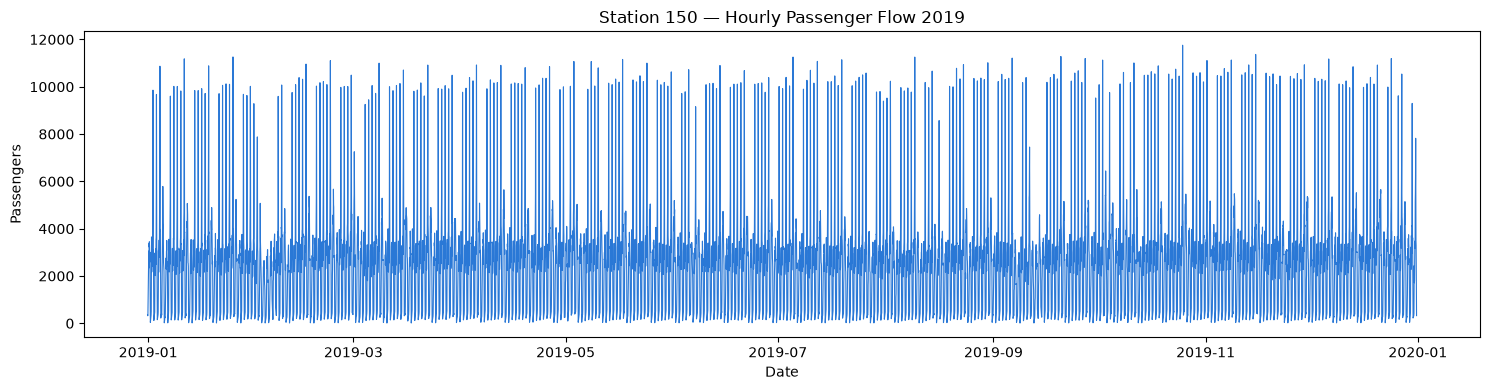

Graph 1 saved


In [2]:
station = df[
    (df['station_code'] == 150) &
    (df['year'] == 2019)
].copy()
station = station.sort_values('timestamp')

plt.figure(figsize=(15, 4))
plt.plot(station['timestamp'],
         station['people_in'],
         color='#2a78d6', linewidth=0.8)
plt.title('Station 150 — Hourly Passenger Flow 2019')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.tight_layout()
plt.savefig('../outputs/graph1_station_flow.png')
plt.show()
print("Graph 1 saved")

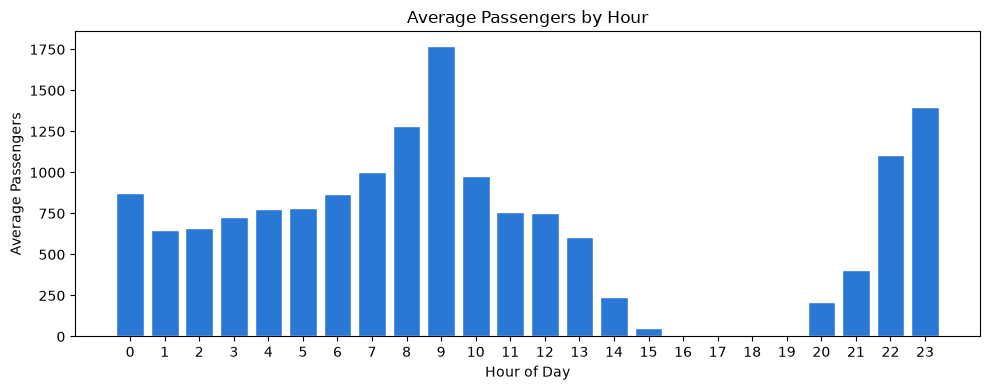

Graph 2 saved


In [3]:
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

hourly = df.groupby('hour')['people_in'].mean().round(0)

plt.figure(figsize=(10, 4))
plt.bar(hourly.index, hourly.values,
        color='#2a78d6', edgecolor='white')
plt.title('Average Passengers by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passengers')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../outputs/graph2_hourly.png')
plt.show()
print("Graph 2 saved")

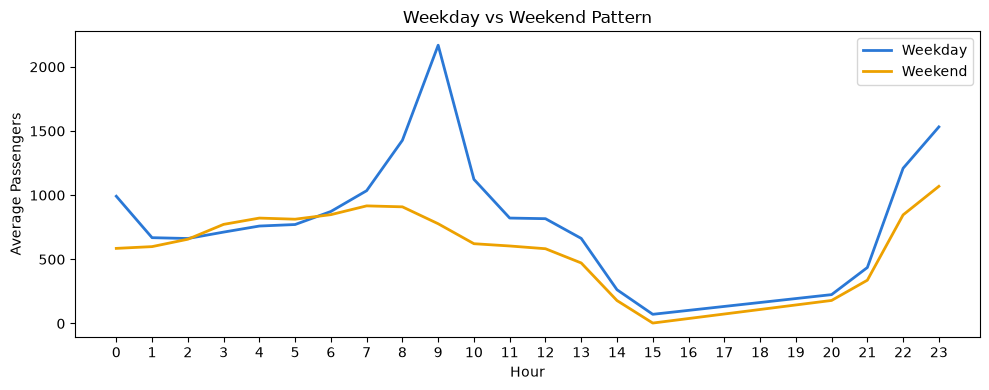

Graph 3 saved


In [4]:
df['day_of_week'] = pd.to_datetime(
    df['timestamp']).dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

weekday = df[df['is_weekend']==0].groupby(
    'hour')['people_in'].mean()
weekend = df[df['is_weekend']==1].groupby(
    'hour')['people_in'].mean()

plt.figure(figsize=(10, 4))
plt.plot(weekday.index, weekday.values,
         label='Weekday', color='#2a78d6', linewidth=2)
plt.plot(weekend.index, weekend.values,
         label='Weekend', color='#eda100', linewidth=2)
plt.title('Weekday vs Weekend Pattern')
plt.xlabel('Hour')
plt.ylabel('Average Passengers')
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../outputs/graph3_weekday_weekend.png')
plt.show()
print("Graph 3 saved")

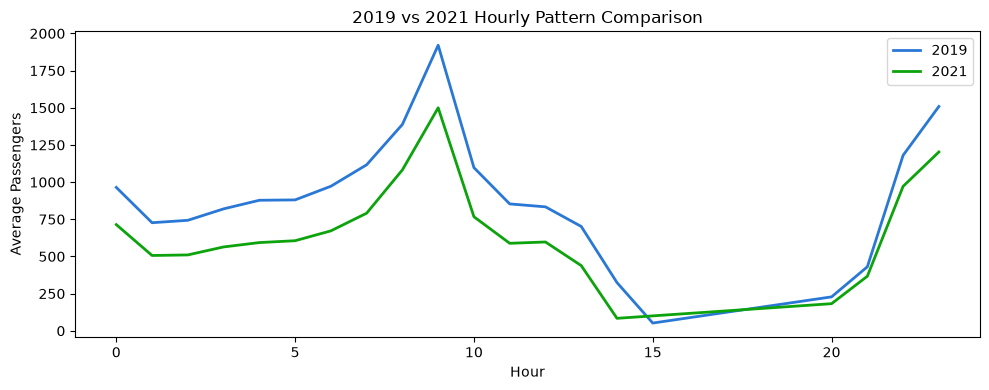

Graph 4 saved


In [5]:
yr2019 = df[df['year']==2019].groupby(
    'hour')['people_in'].mean()
yr2021 = df[df['year']==2021].groupby(
    'hour')['people_in'].mean()

plt.figure(figsize=(10, 4))
plt.plot(yr2019.index, yr2019.values,
         label='2019', color='#2a78d6', linewidth=2)
plt.plot(yr2021.index, yr2021.values,
         label='2021', color='#0ca30c', linewidth=2)
plt.title('2019 vs 2021 Hourly Pattern Comparison')
plt.xlabel('Hour')
plt.ylabel('Average Passengers')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/graph4_year_comparison.png')
plt.show()
print("Graph 4 saved")

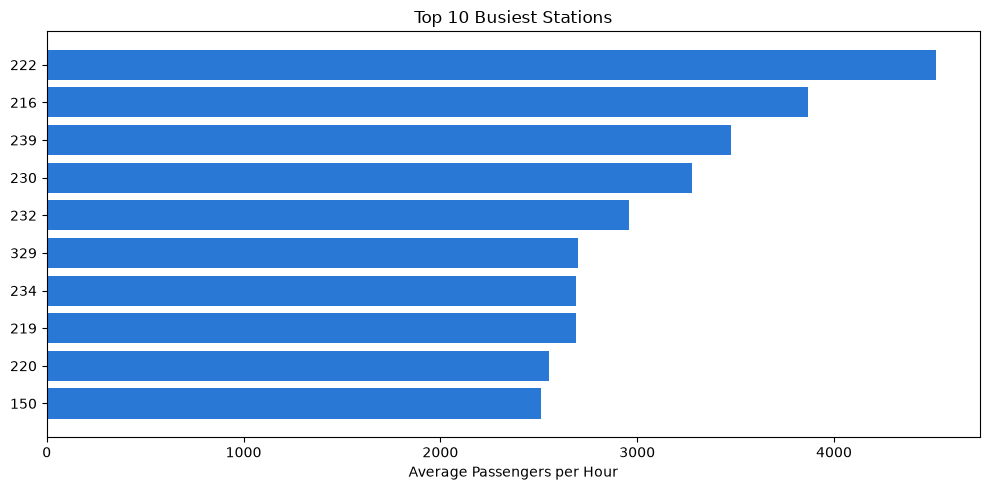

Graph 5 saved


In [6]:
top10 = df.groupby('station_code')[
    'people_in'].mean().nlargest(10)

plt.figure(figsize=(10, 5))
plt.barh(top10.index.astype(str),
         top10.values, color='#2a78d6')
plt.title('Top 10 Busiest Stations')
plt.xlabel('Average Passengers per Hour')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/graph5_top_stations.png')
plt.show()
print("Graph 5 saved")